# 🔬 Lab 10: Clustering
**BINF 4002 – Machine Learning for Health**

Every lab so far has been **supervised** — you had labels (diagnosis, severity grade,
event times, tumor radius) and trained a model to predict them. But in many clinical
settings, labels are expensive, ambiguous, or simply don't exist yet. Psychiatric
diagnoses overlap. Disease subtypes are debated. Phenotypic groups within a patient
population may not have been discovered.

**Clustering** is the most fundamental unsupervised learning task: given data without
labels, discover groups (clusters) of similar patients. There is no "correct answer"
to optimize against — instead, the algorithm must impose structure based on some
notion of similarity. This makes both the objective function and the evaluation
fundamentally different from anything in Labs 1–9.

We return to the Wisconsin Breast Cancer dataset — but this time, we **withhold the
labels entirely** and ask: can an unsupervised algorithm recover the malignant/benign
distinction, or something even more interesting?

### Learning Objectives
1. Understand clustering as an unsupervised task with no single "correct" loss
2. Implement K-Means objective (inertia) by hand; understand Lloyd's algorithm
3. Compare K-Means, hierarchical clustering, and DBSCAN
4. Evaluate clustering quality with internal metrics (silhouette, Calinski-Harabasz) and external metrics (ARI, NMI against withheld labels)

## Set-up
### Upload data
⚠️ First, you need to upload the pre-processed data from `lab0`. If you have issues with running the first lab, you can also download the data [here](https://drive.google.com/file/d/1mCz8VqpX0F5DzOTnfb5NzpxNAMBrzD-_/view?usp=drive_link).

Once you have downloaded the data locally and started the runtime for this notebook, upload the file to this notebook via the "Files" menu.

In [1]:
import os

pkl_path = 'processed_data.pkl'
if os.path.exists(pkl_path):
    print("✅ Data File Found!")
else:
    raise FileNotFoundError(
        "processed_data.pkl not found! "
        "Make sure you have run Lab 0 (lab0_preprocessing.ipynb) in full and "
        "downloaded the output (or used the link above), and uploaded it here."
    )

✅ Data File Found!


### Imports and Data Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

# ── Load data ─────────────────────────────────────────────────────────────────
with open('processed_data.pkl', 'rb') as f:
    d = pickle.load(f)

# For clustering we combine ALL splits — there's no train/val/test in unsupervised learning.
# (We'll use the withheld labels later for external validation only.)
X = np.vstack([d['X_train'], d['X_val'], d['X_test']])
feature_names = d['feature_names']

# Withhold the labels — pretend we don't have them!
y_true_hidden = np.concatenate([d['y_train'], d['y_val'], d['y_test']])
class_names_hidden = d['class_names']  # ['malignant', 'benign']

n_samples, n_features = X.shape
print(f"Dataset: {n_samples} patients, {n_features} standardized features")
print(f"Features: {feature_names[:5]} ... ({n_features} total)")
print(f"\n⚠️ Labels are WITHHELD. We do not know the diagnosis.")
print(f"   The goal: discover structure from features alone.")

Dataset: 569 patients, 30 standardized features
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] ... (30 total)

⚠️ Labels are WITHHELD. We do not know the diagnosis.
   The goal: discover structure from features alone.


---
## Part 1 — Motivation: Learning Without Labels

In supervised learning, you know what you're looking for. In clustering, you don't.
You're asking the data: "Are there natural groups here?" This is both powerful
(you might discover something unexpected) and dangerous (you might find structure
that isn't real).

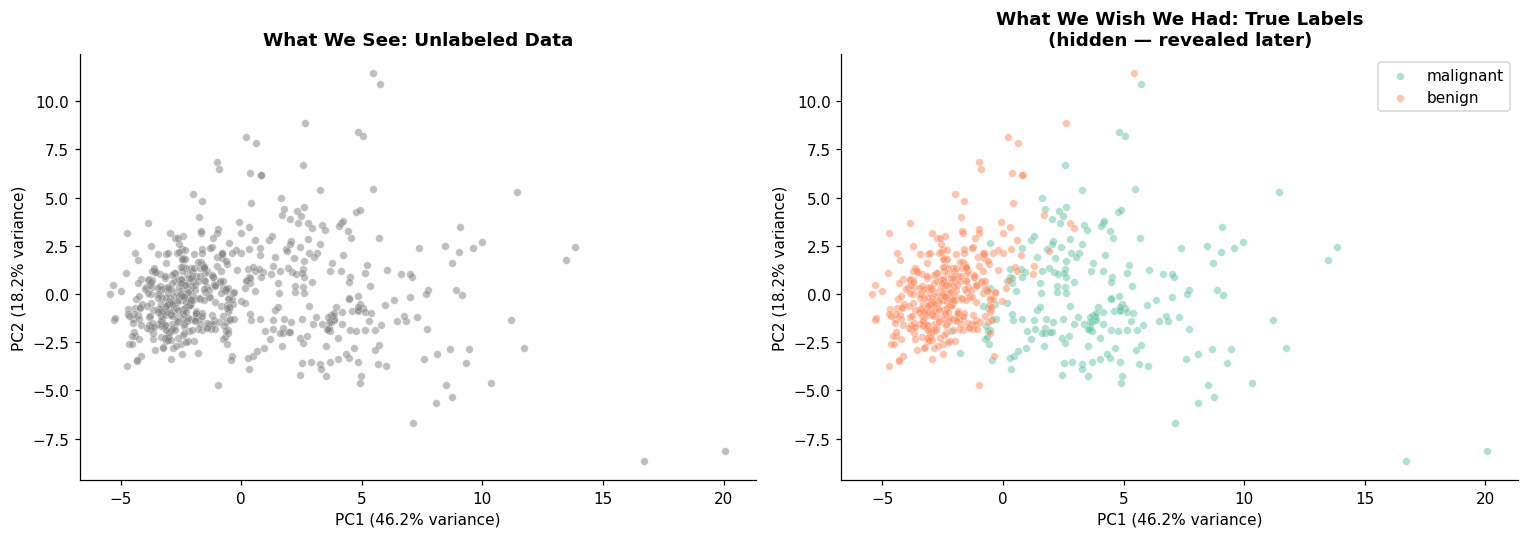

The left plot is all we have. Can clustering recover the structure on the right?
(Resist the temptation to peek at the right plot — pretend you can't see it.)


In [3]:
# ── PCA projection — no labels ───────────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# What WE see: no labels
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=25, color='gray',
           edgecolors='white', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('What We See: Unlabeled Data', fontweight='bold')

# What we WISH we had: colored by (hidden) labels
ax = axes[1]
colors = sns.color_palette('Set2', 2)
for k, name in enumerate(class_names_hidden):
    mask = y_true_hidden == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=25, color=colors[k],
               edgecolors='white', linewidth=0.3, label=name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('What We Wish We Had: True Labels\n(hidden — revealed later)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

print("The left plot is all we have. Can clustering recover the structure on the right?")
print("(Resist the temptation to peek at the right plot — pretend you can't see it.)")

### 🤔 Reflection 1.1 — Why Cluster?

1. In many clinical settings, labels are expensive or ambiguous (e.g., psychiatric
   diagnoses, disease subtypes, treatment response phenotypes). Why might an
   unsupervised approach be valuable even when *some* labels exist?

2. Looking at the left (unlabeled) scatter plot, do you see any structure? How many
   groups would you guess there are? (This is surprisingly hard for humans in 2D,
   and even harder in the original 30D space.)

3. Clustering imposes structure on data. How would you distinguish genuine biological
   clusters from artifacts of the algorithm or the features chosen?

---
## Part 2 — K-Means: The Objective and the Algorithm

K-Means is the most widely used clustering algorithm. It partitions $n$ points into
$K$ clusters by minimizing the **within-cluster sum of squares (WCSS)**, also called
**inertia**:

$$J = \sum_{k=1}^{K} \sum_{i \in C_k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$

where $C_k$ is the set of points in cluster $k$ and $\boldsymbol{\mu}_k$ is the
centroid (mean) of cluster $k$.

**Lloyd's algorithm** alternates two steps:
1. **Assign** each point to the nearest centroid
2. **Update** each centroid to the mean of its assigned points

This monotonically decreases $J$ and converges (but to a local minimum, not necessarily
the global one).

In [4]:
def kmeans_inertia_solution(X, labels, centroids):
    """
    Compute the K-Means objective: J = Σ_k Σ_{i ∈ C_k} ||x_i - μ_k||²
    """
    # centroids[labels] gives each point's assigned centroid (shape n, d)
    diffs = X - centroids[labels]
    inertia = np.sum(diffs ** 2)
    return inertia


# Verify
X_toy = np.array([[0, 0], [1, 0], [10, 0], [11, 0]], dtype=float)
labels_toy = np.array([0, 0, 1, 1])
centroids_toy = np.array([[0.5, 0], [10.5, 0]])
print(f"Toy inertia: {kmeans_inertia_solution(X_toy, labels_toy, centroids_toy):.4f}  (should be 1.0)")


Toy inertia: 1.0000  (should be 1.0)


In [5]:
def kmeans_lloyd_solution(X, K, n_iter=20, seed=42):
    """
    Run K-Means via Lloyd's algorithm.
    """
    np.random.seed(seed)
    n, d = X.shape

    # Initialize: pick K random data points as centroids
    init_idx = np.random.choice(n, K, replace=False)
    centroids = X[init_idx].copy()

    inertia_history = []

    for iteration in range(n_iter):
        # Step 1: ASSIGN — compute squared distances, take argmin
        distances = np.array([np.sum((X - centroids[k]) ** 2, axis=1) for k in range(K)]).T
        labels = np.argmin(distances, axis=1)

        # Step 2: UPDATE — set each centroid to the mean of its members
        new_centroids = np.zeros_like(centroids)
        for k in range(K):
            members = X[labels == k]
            if len(members) > 0:
                new_centroids[k] = members.mean(axis=0)
            else:
                new_centroids[k] = centroids[k]

        centroids = new_centroids

        # Track objective
        J = kmeans_inertia_solution(X, labels, centroids)
        inertia_history.append(J)

    return labels, centroids, inertia_history


# Verify
labels_sol, centroids_sol, history_sol = kmeans_lloyd_solution(X, K=2, n_iter=30, seed=42)
print(f"Solution K-Means (K=2): final inertia = {history_sol[-1]:.2f}")
print(f"Cluster sizes: {np.bincount(labels_sol)}")


Solution K-Means (K=2): final inertia = 11691.37
Cluster sizes: [391 178]


NameError: name 'history_ours' is not defined

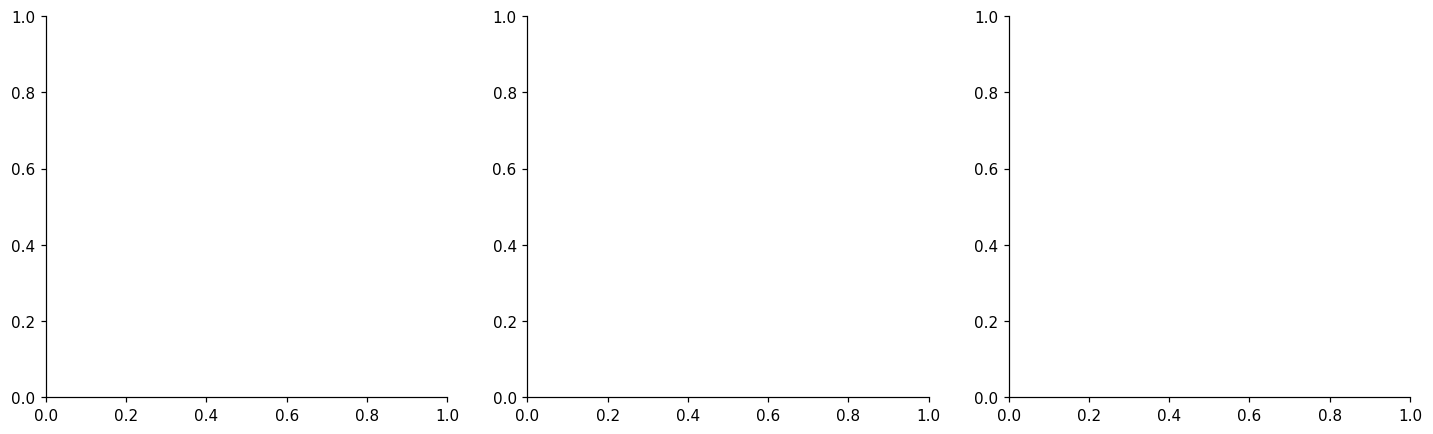

In [6]:
# ── Plot convergence and compare to sklearn ──────────────────────────────────
from sklearn.cluster import KMeans

km_sk = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_sk = km_sk.fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Convergence plot
ax = axes[0]
ax.plot(history_ours, 'o-', markersize=3, linewidth=2)
ax.axhline(km_sk.inertia_, color='red', linestyle='--', label=f'sklearn ({km_sk.inertia_:.0f})')
ax.set_xlabel('Iteration')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Lloyd\'s Algorithm Convergence', fontweight='bold')
ax.legend(fontsize=9)

# Our clusters in PCA space
ax = axes[1]
for k in range(2):
    mask = labels_ours == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=25,
               edgecolors='white', linewidth=0.3, label=f'Cluster {k}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('Our K-Means (K=2)', fontweight='bold')
ax.legend(fontsize=9)

# sklearn clusters
ax = axes[2]
for k in range(2):
    mask = labels_sk == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=25,
               edgecolors='white', linewidth=0.3, label=f'Cluster {k}')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('sklearn KMeans (K=2)', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

NameError: name 'kmeans_lloyd' is not defined

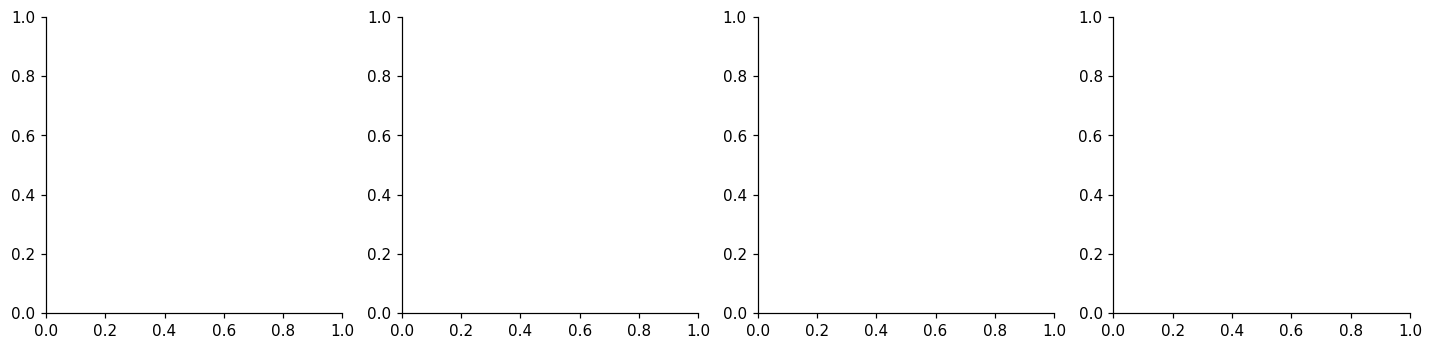

In [7]:
# ── Different initializations give different results! ────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
inertias = []

for i, seed in enumerate([0, 7, 13, 42]):
    labels_s, _, history_s = kmeans_lloyd(X, K=2, n_iter=30, seed=seed)
    inertias.append(history_s[-1])
    ax = axes[i]
    for k in range(2):
        mask = labels_s == k
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=15,
                   edgecolors='white', linewidth=0.2)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'seed={seed}\nJ={history_s[-1]:.0f}', fontsize=10, fontweight='bold')

plt.suptitle('Same Algorithm, Different Random Starts → Different Results',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Inertias: {[f'{j:.0f}' for j in inertias]}")
print(f"Range: {max(inertias) - min(inertias):.0f}")
print("→ K-Means finds LOCAL minima. sklearn's n_init=10 runs 10 starts and keeps the best.")

### 🤔 Reflection 2.1 — K-Means Assumptions

1. K-Means minimizes inertia, which implicitly assumes clusters are **spherical** and
   roughly **equal-sized**. When might this assumption be badly wrong in clinical data?
   (Hint: malignant tumors might form a small, spread-out cluster, while benign tumors
   form a large, tight cluster.)

2. Lloyd's algorithm converges, but to a **local** minimum. You just saw that different
   initializations give different results. Why is this a problem, and what does sklearn's
   `n_init=10` do about it?

3. The inertia objective always decreases as you add more iterations. But does lower
   inertia always mean a better clustering? (Hint: inertia also decreases as K increases.)

---
## Part 3 — Choosing K: The Elbow, Silhouette, and Gap Statistic

K-Means requires you to specify $K$ in advance. How do you choose it?

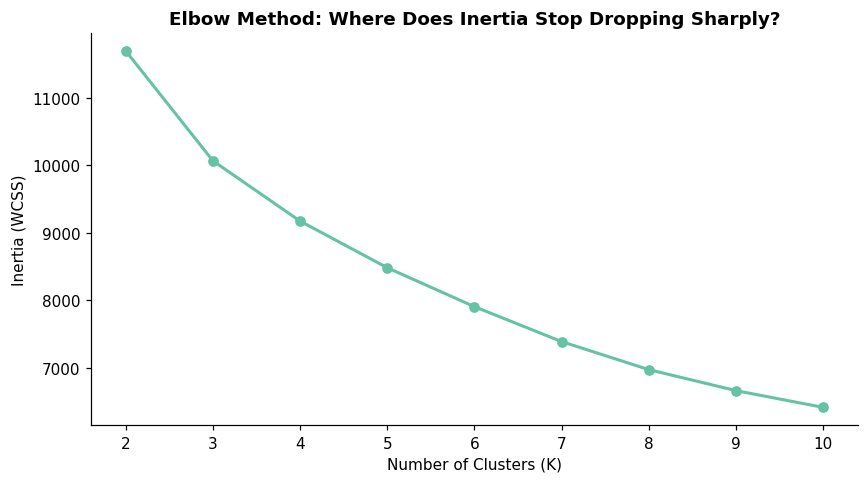

The 'elbow' is where adding another cluster gives diminishing returns.
It's often subjective — that's a fundamental limitation of the elbow method.


In [8]:
# ── Elbow method: inertia vs. K ──────────────────────────────────────────────
K_range = range(2, 11)
inertias_k = []
km_models = {}

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias_k.append(km.inertia_)
    km_models[k] = km

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(K_range), inertias_k, 'o-', markersize=6, linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('Elbow Method: Where Does Inertia Stop Dropping Sharply?', fontweight='bold')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print("The 'elbow' is where adding another cluster gives diminishing returns.")
print("It's often subjective — that's a fundamental limitation of the elbow method.")

In [9]:
def silhouette_single_solution(X, labels, i):
    """
    Compute the silhouette score for a single point i.
    """
    K = len(np.unique(labels))
    my_cluster = labels[i]

    # a(i): mean distance to other points in same cluster
    same_mask = (labels == my_cluster)
    same_mask[i] = False
    if same_mask.sum() == 0:
        return 0.0

    dists_to_same = np.sqrt(np.sum((X[same_mask] - X[i])**2, axis=1))
    a_i = dists_to_same.mean()

    # b(i): min over other clusters of mean distance
    b_i = np.inf
    for k in range(K):
        if k == my_cluster:
            continue
        other_mask = (labels == k)
        if other_mask.sum() == 0:
            continue
        dists_to_other = np.sqrt(np.sum((X[other_mask] - X[i])**2, axis=1))
        mean_dist_k = dists_to_other.mean()
        b_i = min(b_i, mean_dist_k)

    # s(i)
    s_i = (b_i - a_i) / max(a_i, b_i)
    return s_i


# Verify against sklearn
from sklearn.metrics import silhouette_samples
labels_k2 = km_models[2].labels_
our_scores = [silhouette_single_solution(X, labels_k2, i) for i in range(50)]
sk_scores = silhouette_samples(X, labels_k2)[:50]
max_diff = np.max(np.abs(np.array(our_scores) - sk_scores))
print(f"Max difference (first 50 points): {max_diff:.2e}  "
      f"{'✅ Match!' if max_diff < 1e-10 else '⚠️ Check'}")


Max difference (first 50 points): 1.22e-15  ✅ Match!


In [10]:
# ── Silhouette plot and K selection ──────────────────────────────────────────
from sklearn.metrics import calinski_harabasz_score

sil_scores = [silhouette_score(X, km_models[k].labels_) for k in K_range]
ch_scores  = [calinski_harabasz_score(X, km_models[k].labels_) for k in K_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(list(K_range), sil_scores, 'o-', markersize=6, linewidth=2)
best_k_sil = list(K_range)[np.argmax(sil_scores)]
ax.axvline(best_k_sil, color='red', linestyle='--', alpha=0.5,
           label=f'Best K={best_k_sil}')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score vs. K\n(higher = better)', fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()

ax = axes[1]
ax.plot(list(K_range), ch_scores, 'o-', markersize=6, linewidth=2,
        color=sns.color_palette('Set2')[1])
best_k_ch = list(K_range)[np.argmax(ch_scores)]
ax.axvline(best_k_ch, color='red', linestyle='--', alpha=0.5,
           label=f'Best K={best_k_ch}')
ax.set_xlabel('K'); ax.set_ylabel('Calinski-Harabasz Score')
ax.set_title('Calinski-Harabasz Score vs. K\n(higher = better)', fontweight='bold')
ax.set_xticks(list(K_range))
ax.legend()

plt.tight_layout()
plt.show()

print(f"Best K by silhouette: {best_k_sil}")
print(f"Best K by Calinski-Harabasz: {best_k_ch}")
print(f"Remember: the data has 2 true classes. Do the metrics agree?")

NameError: name 'silhouette_score' is not defined

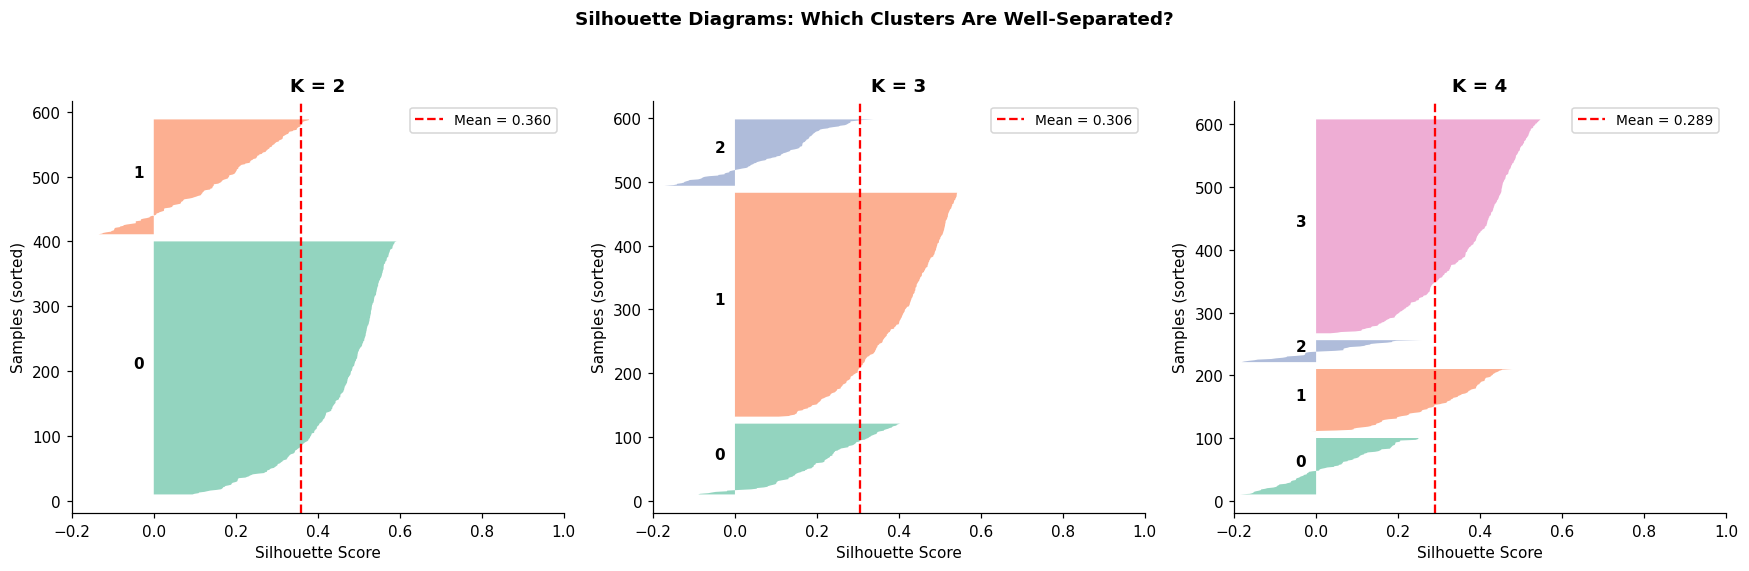

Wider bars = larger clusters. Points near 0 or negative = poorly assigned.
A good clustering has most points with high silhouette and similar-width bars.


In [11]:
# ── Silhouette diagrams for K = 2, 3, 4 ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [2, 3, 4]):
    labels_k = km_models[k].labels_
    sil_vals = silhouette_samples(X, labels_k)
    avg_sil = sil_vals.mean()

    y_lower = 10
    for cluster_id in range(k):
        cluster_sil = np.sort(sil_vals[labels_k == cluster_id])
        cluster_size = len(cluster_sil)
        y_upper = y_lower + cluster_size

        color = sns.color_palette('Set2', k)[cluster_id]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         alpha=0.7, facecolor=color, edgecolor='none')
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(cluster_id),
                fontweight='bold', fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(avg_sil, color='red', linestyle='--',
               label=f'Mean = {avg_sil:.3f}')
    ax.set_xlabel('Silhouette Score')
    ax.set_ylabel('Samples (sorted)')
    ax.set_title(f'K = {k}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.2, 1.0)

plt.suptitle('Silhouette Diagrams: Which Clusters Are Well-Separated?',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Wider bars = larger clusters. Points near 0 or negative = poorly assigned.")
print("A good clustering has most points with high silhouette and similar-width bars.")

### 🤔 Reflection 3.1 — Is K=2 the "Right" Answer?

1. The data originally had 2 classes (malignant/benign). Does K=2 give the highest
   silhouette score? If not, what might that mean — is the "true" structure richer
   than a binary label suggests?

2. The elbow method is notoriously subjective. The silhouette score gives a concrete
   optimum. But do they agree? When metrics disagree, what should you do?

3. Is there a "correct" number of clusters? Or does it depend on what clinical
   question you're asking? (K=2 for diagnosis, K=4 for treatment subgroups, etc.)

---
## Part 4 — Alternative Algorithms

K-Means assumes spherical, equal-sized clusters. Other algorithms make different
assumptions. Before using them, let's briefly understand what each one does.

### Hierarchical (Agglomerative) Clustering

Hierarchical clustering builds a **tree of nested clusters** (a *dendrogram*) by
iteratively merging the two most similar clusters, starting from individual points.

**How it works:**
1. Start with each point as its own cluster ($n$ clusters total).
2. Compute the distance between all pairs of clusters.
3. Merge the two closest clusters into one.
4. Repeat steps 2–3 until only one cluster remains.

The **linkage criterion** determines how "distance between clusters" is defined:
- **Ward linkage**: merges the pair of clusters that causes the smallest increase in
  total within-cluster variance. Tends to produce compact, spherical clusters (similar
  to K-Means).
- **Complete linkage**: uses the *maximum* distance between any two points in the two
  clusters. Tends to produce clusters of similar diameter.
- **Average linkage**: uses the *average* distance between all pairs of points. A
  compromise between Ward and complete linkage.

**Key advantage:** you get a full hierarchy — cutting the dendrogram at different
heights gives different numbers of clusters, without re-running the algorithm.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

DBSCAN takes a fundamentally different approach: it defines clusters as **dense
regions** of points separated by sparse regions.

**How it works:**
1. For each point, count how many other points are within a radius $\varepsilon$ (eps).
2. If a point has at least `min_samples` neighbors within $\varepsilon$, it is a
   **core point** — it is part of a dense region.
3. **Core points** that are within $\varepsilon$ of each other are placed in the same cluster.
4. **Border points** that are within $\varepsilon$ of a core point (but are not
   themselves core) are assigned to that cluster.
5. Points that are not within $\varepsilon$ of *any* core point are labeled as
   **noise** — they don't belong to any cluster.

**Key advantages:**
- Does **not require specifying K** — the number of clusters is discovered automatically.
- Can find clusters of **arbitrary shape** (not just spherical).
- Explicitly identifies **outliers/noise** — points that don't belong to any cluster.

**Key limitations:**
- Sensitive to $\varepsilon$ and `min_samples` — choosing these requires some care.
- Struggles with clusters of **varying density** (a single $\varepsilon$ can't capture
  both tight and spread-out clusters).


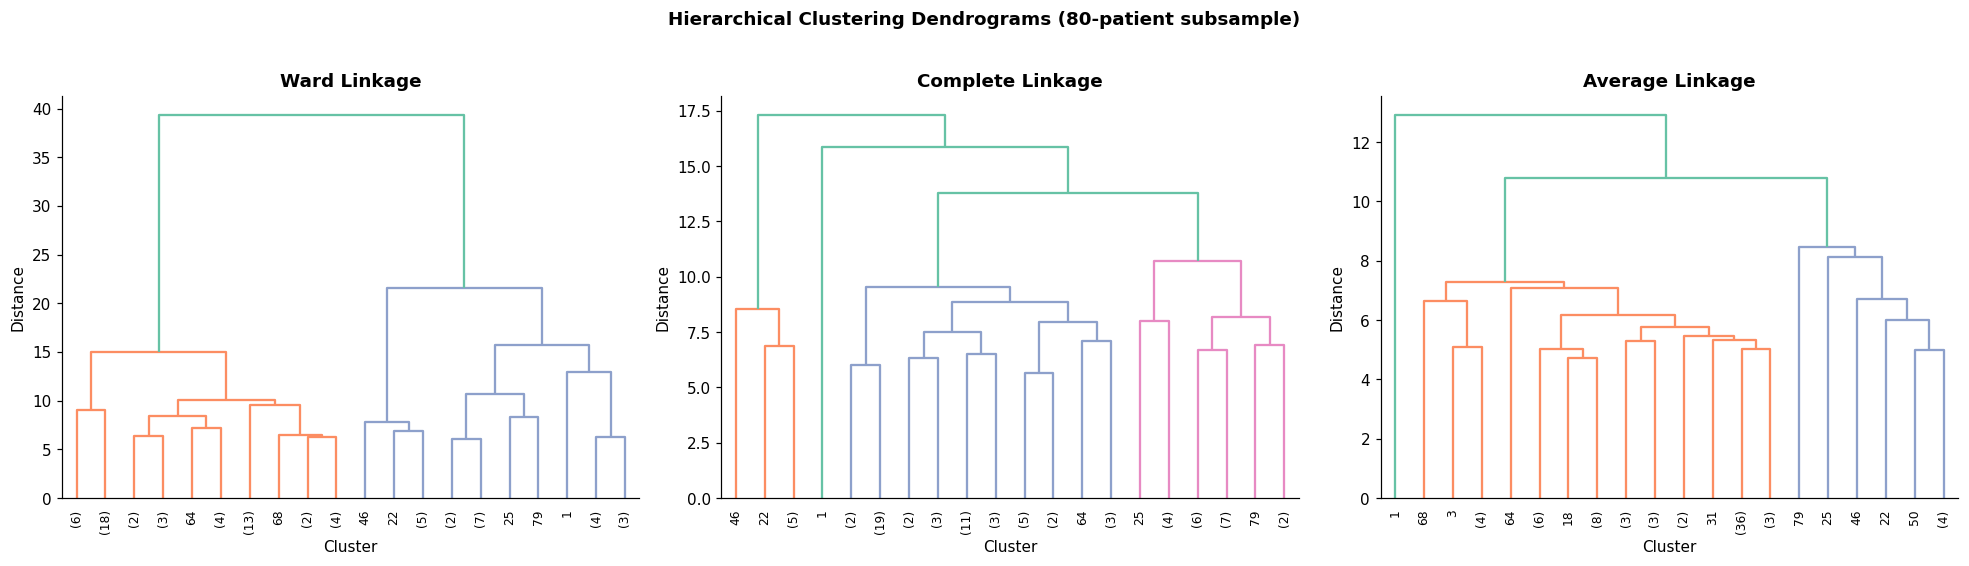


Ward clustering (K=2): cluster sizes = [213 356]


NameError: name 'silhouette_score' is not defined

In [12]:
# ── Hierarchical (Agglomerative) Clustering ──────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Dendrograms (on a random subsample for readability)
np.random.seed(42)
sub_idx = np.random.choice(n_samples, 80, replace=False)
X_sub = X[sub_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, ['ward', 'complete', 'average']):
    Z = linkage(X_sub, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=20, leaf_rotation=90,
               leaf_font_size=8, show_leaf_counts=True)
    ax.set_title(f'{method.capitalize()} Linkage', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering Dendrograms (80-patient subsample)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Fit on full data with K=2
agg_ward = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels_ward = agg_ward.fit_predict(X)

print(f"\nWard clustering (K=2): cluster sizes = {np.bincount(labels_ward)}")
print(f"Silhouette: {silhouette_score(X, labels_ward):.3f}")

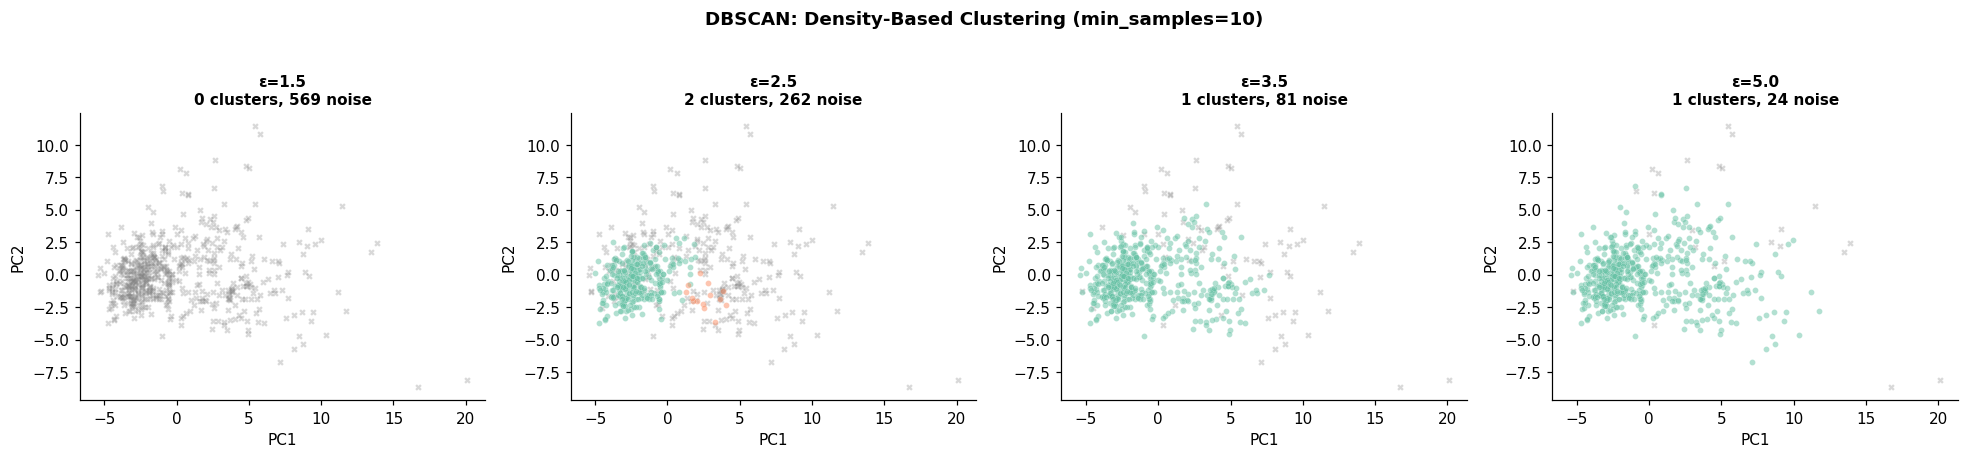

DBSCAN discovers clusters of arbitrary shape and labels sparse points as 'noise.'
The ε parameter controls what 'dense enough' means — too small → everything is noise,
too large → everything is one cluster.


In [13]:
# ── DBSCAN ───────────────────────────────────────────────────────────────────
from sklearn.cluster import DBSCAN

# DBSCAN doesn't require K — it finds clusters based on density.
# Two parameters: eps (neighborhood radius) and min_samples (minimum points per cluster)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
eps_values = [1.5, 2.5, 3.5, 5.0]

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=10)
    labels_db = db.fit_predict(X)

    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = (labels_db == -1).sum()

    # Color by cluster, noise in gray
    unique_labels = set(labels_db)
    colors_db = sns.color_palette('Set2', max(n_clusters, 1))
    for k_label in sorted(unique_labels):
        mask = labels_db == k_label
        if k_label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c='gray', alpha=0.3,
                       s=10, marker='x', label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=15,
                       color=colors_db[k_label % len(colors_db)],
                       edgecolors='white', linewidth=0.2)

    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'ε={eps}\n{n_clusters} clusters, {n_noise} noise',
                 fontweight='bold', fontsize=10)

plt.suptitle('DBSCAN: Density-Based Clustering (min_samples=10)',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("DBSCAN discovers clusters of arbitrary shape and labels sparse points as 'noise.'")
print("The ε parameter controls what 'dense enough' means — too small → everything is noise,")
print("too large → everything is one cluster.")

### 🤔 Reflection 4.1 — Algorithm Assumptions

1. DBSCAN found some points as "noise" — samples that don't belong to any dense
   cluster. Could these correspond to ambiguous or borderline tumors? How does
   DBSCAN's density-based approach differ from K-Means' centroid-based approach
   in terms of cluster *shape*?

2. Hierarchical clustering with Ward linkage tends to find compact, spherical clusters
   (similar to K-Means). Average or complete linkage can find elongated or irregular
   clusters. Looking at the dendrograms, do you see a clear 2-cluster split?

3. K-Means, hierarchical, and DBSCAN each embed different assumptions about cluster
   structure. In a clinical discovery setting where you don't know the true clusters,
   how would you decide which algorithm to trust?

---
## Part 5 — External Validation: Comparing to Ground Truth

Now we **reveal the withheld labels** and check how well the unsupervised clusters
match the true malignant/benign diagnoses.

Two key external metrics:
- **Adjusted Rand Index (ARI):** measures agreement between two clusterings, corrected
  for chance. ARI=1 means perfect agreement, ARI=0 means random.
- **Normalized Mutual Information (NMI):** measures shared information between
  clusterings. NMI=1 means knowing one tells you the other perfectly.

In [14]:
# ── Reveal the truth! ────────────────────────────────────────────────────────
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                              confusion_matrix, ConfusionMatrixDisplay)

print("🔓 Revealing the withheld labels!")
print(f"   True classes: {class_names_hidden}")
print(f"   Distribution: {dict(zip(class_names_hidden, np.bincount(y_true_hidden)))}")

# Compare K=2 K-Means to true labels
labels_k2 = km_models[2].labels_
ari_k2 = adjusted_rand_score(y_true_hidden, labels_k2)
nmi_k2 = normalized_mutual_info_score(y_true_hidden, labels_k2)

# Also compare Ward
ari_ward = adjusted_rand_score(y_true_hidden, labels_ward)
nmi_ward = normalized_mutual_info_score(y_true_hidden, labels_ward)

print(f"\n{'Algorithm':20s} {'ARI':>8s} {'NMI':>8s}")
print("─" * 38)
print(f"{'K-Means (K=2)':20s} {ari_k2:8.3f} {nmi_k2:8.3f}")
print(f"{'Ward (K=2)':20s} {ari_ward:8.3f} {nmi_ward:8.3f}")
print(f"{'Random':20s} {'~0':>8s} {'~0':>8s}")
print(f"{'Perfect':20s} {'1.0':>8s} {'1.0':>8s}")

🔓 Revealing the withheld labels!
   True classes: ['malignant', 'benign']
   Distribution: {'malignant': np.int64(212), 'benign': np.int64(357)}

Algorithm                 ARI      NMI
──────────────────────────────────────
K-Means (K=2)           0.700    0.604
Ward (K=2)              0.672    0.548
Random                     ~0       ~0
Perfect                   1.0      1.0


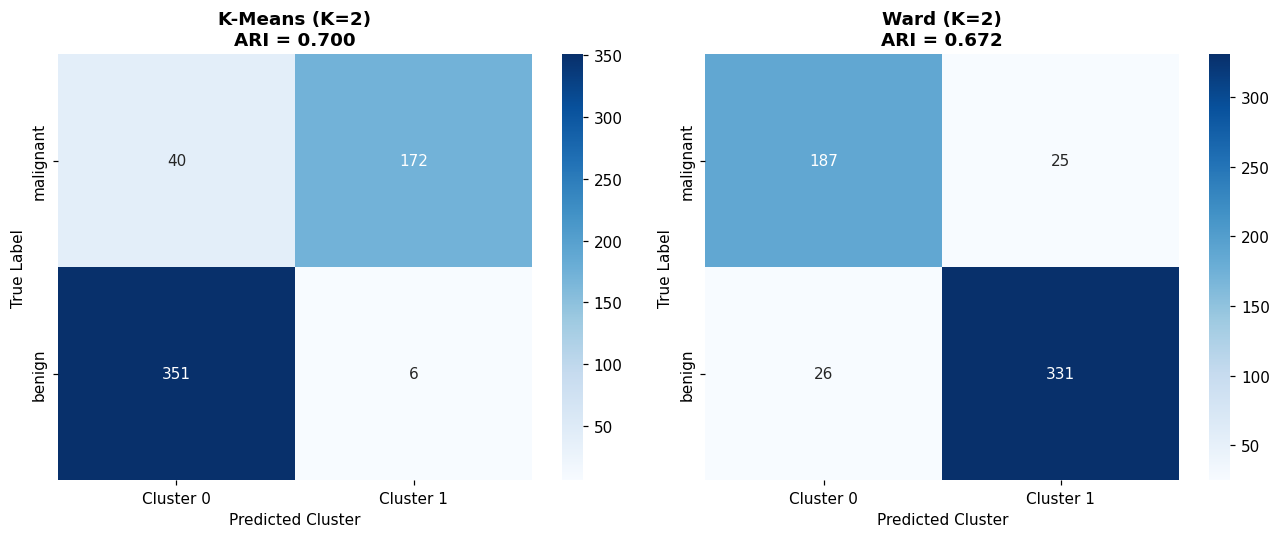

Note: cluster labels are arbitrary — 'Cluster 0' might correspond to either class.
The confusion matrix shows how the clusters align with the true diagnosis.
Mismatches = patients placed in the 'wrong' cluster relative to their diagnosis.


In [15]:
# ── Confusion matrix: clusters vs. true labels ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels_pred, title in zip(axes,
    [labels_k2, labels_ward],
    ['K-Means (K=2)', 'Ward (K=2)']):

    # Note: cluster labels are arbitrary (0/1), so we show the raw confusion matrix
    cm = confusion_matrix(y_true_hidden, labels_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Cluster 0', 'Cluster 1'],
                yticklabels=class_names_hidden)
    ari = adjusted_rand_score(y_true_hidden, labels_pred)
    ax.set_title(f'{title}\nARI = {ari:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted Cluster'); ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

print("Note: cluster labels are arbitrary — 'Cluster 0' might correspond to either class.")
print("The confusion matrix shows how the clusters align with the true diagnosis.")
print("Mismatches = patients placed in the 'wrong' cluster relative to their diagnosis.")

### 🤔 Reflection 5.1 — Interpreting External Validation

1. Your K=2 clustering achieves a certain ARI against the true labels. Is this
   "good"? Consider: ARI=1 means perfect recovery of the labels, ARI=0 means random,
   and typical values for real clinical data are 0.3–0.7.

2. Some malignant tumors are grouped with benign ones (and vice versa). Are these
   likely borderline cases, data errors, or a failure of the algorithm? How would
   you investigate this? (Hint: look at the feature values of the misassigned patients.)

3. Why is ARI preferred over raw accuracy for cluster evaluation? (Hint: cluster
   labels are arbitrary — "cluster 0" doesn't inherently mean "benign." ARI
   handles this by measuring agreement regardless of label permutation.)

---
## Part 6 — Clustering as a Clinical Discovery Tool

The true power of clustering isn't reproducing known labels — it's **discovering
structure we didn't know about.** What happens when we ask for *more than 2* clusters?

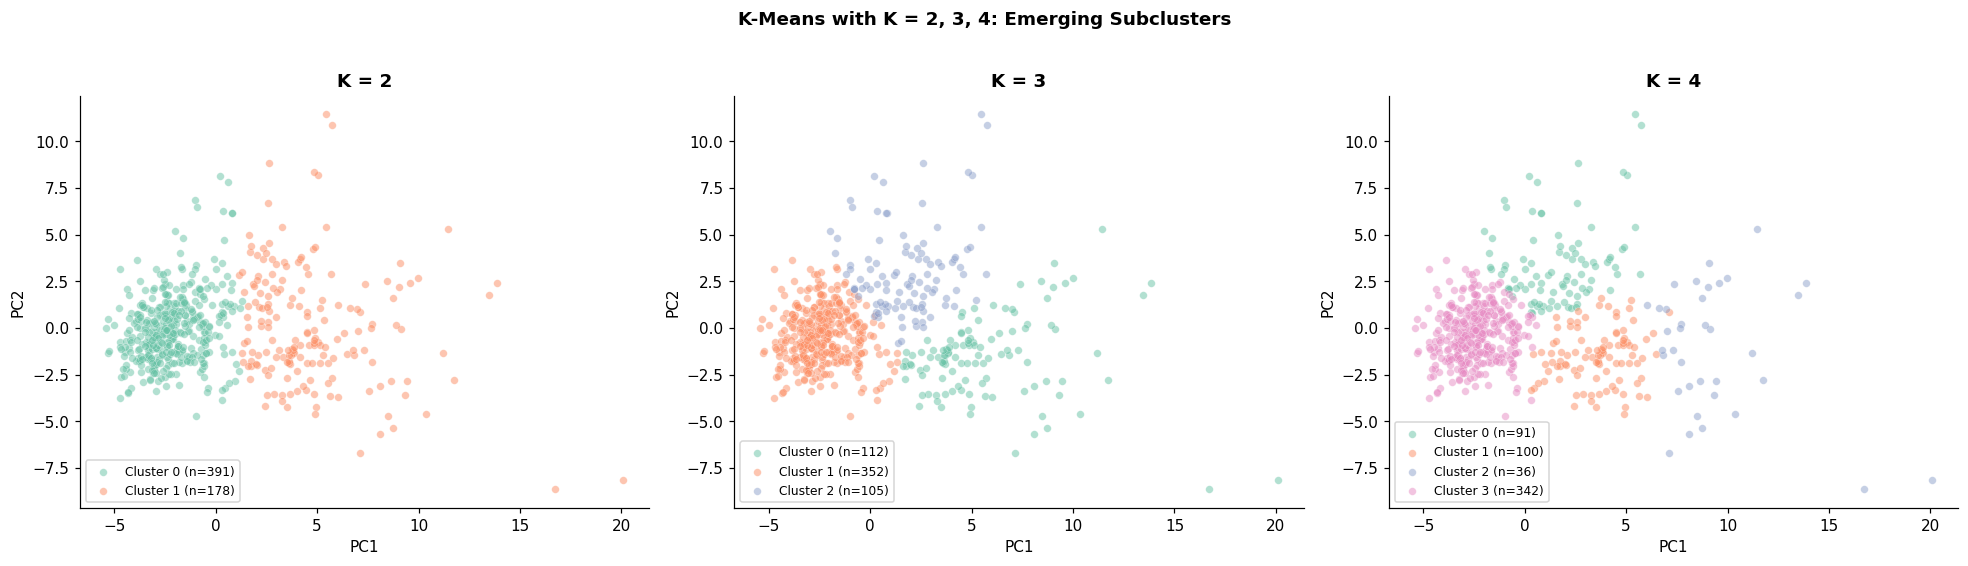

In [16]:
# ── K=3 and K=4: do subclusters emerge? ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [2, 3, 4]):
    labels_k = km_models[k].labels_
    colors_k = sns.color_palette('Set2', k)

    for cl in range(k):
        mask = labels_k == cl
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.5, s=25,
                   color=colors_k[cl], edgecolors='white', linewidth=0.3,
                   label=f'Cluster {cl} (n={mask.sum()})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.set_title(f'K = {k}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')

plt.suptitle('K-Means with K = 2, 3, 4: Emerging Subclusters',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# ── Characterize subclusters: which true class does each cluster contain? ─────
for k in [3, 4]:
    labels_k = km_models[k].labels_
    print(f"\n{'═'*60}")
    print(f"  K = {k} — Subcluster Composition")
    print(f"{'═'*60}")
    for cl in range(k):
        mask = labels_k == cl
        n_mal = (y_true_hidden[mask] == 0).sum()
        n_ben = (y_true_hidden[mask] == 1).sum()
        pct_mal = n_mal / mask.sum() * 100
        dominant = 'Malignant' if pct_mal > 50 else 'Benign'
        print(f"  Cluster {cl}: n={mask.sum():3d} | "
              f"Malignant: {n_mal:3d} ({pct_mal:5.1f}%) | "
              f"Benign: {n_ben:3d} ({100-pct_mal:5.1f}%) → mostly {dominant}")


════════════════════════════════════════════════════════════
  K = 3 — Subcluster Composition
════════════════════════════════════════════════════════════
  Cluster 0: n=112 | Malignant: 112 (100.0%) | Benign:   0 (  0.0%) → mostly Malignant
  Cluster 1: n=352 | Malignant:  32 (  9.1%) | Benign: 320 ( 90.9%) → mostly Benign
  Cluster 2: n=105 | Malignant:  68 ( 64.8%) | Benign:  37 ( 35.2%) → mostly Malignant

════════════════════════════════════════════════════════════
  K = 4 — Subcluster Composition
════════════════════════════════════════════════════════════
  Cluster 0: n= 91 | Malignant:  52 ( 57.1%) | Benign:  39 ( 42.9%) → mostly Malignant
  Cluster 1: n=100 | Malignant: 100 (100.0%) | Benign:   0 (  0.0%) → mostly Malignant
  Cluster 2: n= 36 | Malignant:  36 (100.0%) | Benign:   0 (  0.0%) → mostly Malignant
  Cluster 3: n=342 | Malignant:  24 (  7.0%) | Benign: 318 ( 93.0%) → mostly Benign


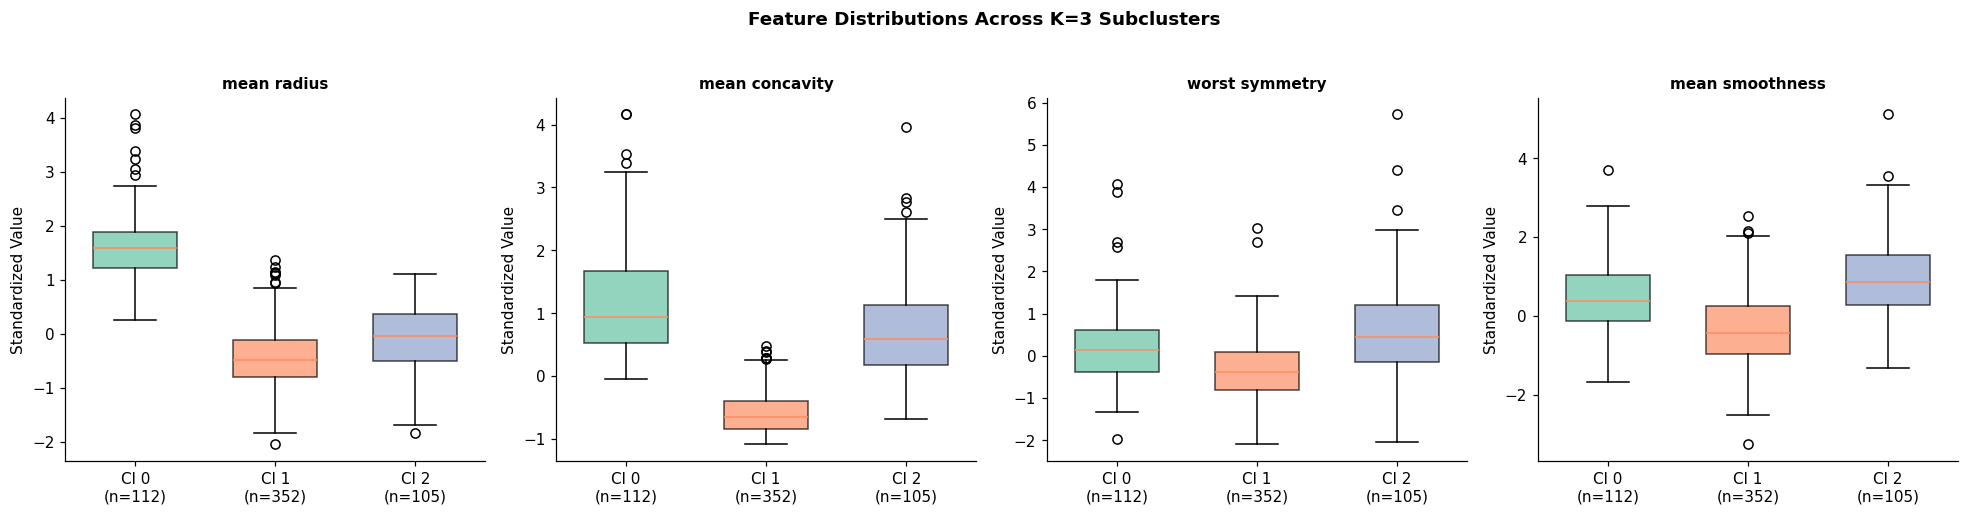

Do the subclusters differ on clinically meaningful features?
If the malignant group splits into subclusters with different feature profiles,
this might represent genuine biological subtypes.


In [18]:
# ── Feature distributions per subcluster (K=3) ───────────────────────────────
labels_k3 = km_models[3].labels_

# Pick 4 clinically interesting features to compare
plot_features = ['mean radius', 'mean concavity', 'worst symmetry', 'mean smoothness']
plot_indices = [feature_names.index(f) for f in plot_features]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
colors_3 = sns.color_palette('Set2', 3)

for ax, feat_name, feat_idx in zip(axes, plot_features, plot_indices):
    data_to_plot = []
    labels_to_plot = []
    for cl in range(3):
        vals = X[labels_k3 == cl, feat_idx]
        data_to_plot.append(vals)
        labels_to_plot.append(f'Cl {cl}\n(n={len(vals)})')

    bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True,
                     widths=0.6)
    for patch, color in zip(bp['boxes'], colors_3):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_ylabel('Standardized Value')
    ax.set_title(feat_name, fontweight='bold', fontsize=10)

plt.suptitle('Feature Distributions Across K=3 Subclusters',
             fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Do the subclusters differ on clinically meaningful features?")
print("If the malignant group splits into subclusters with different feature profiles,")
print("this might represent genuine biological subtypes.")

### 🤔 Reflection 6.1 — Discovering Subtypes

1. With K=3, the malignant group may split into subclusters with different feature
   profiles — perhaps a "large aggressive" and a "small irregular" subtype.
   How would you **validate** this computationally discovered subtype? What evidence
   would a clinician need to see before trusting it?

2. The fact that K>2 might produce a higher silhouette score suggests the binary
   malignant/benign label is a simplification of richer underlying structure.
   Is this surprising? In real oncology, breast cancer has multiple molecular
   subtypes (luminal A/B, HER2+, basal-like) — could clustering rediscover this?

3. A danger of clustering is **overfitting to noise**: with enough clusters, you can
   always find apparent structure. How would you distinguish real subtypes from
   statistical artifacts?

---
## 🤔 Final Reflection

You're given **10,000 unlabeled patient records** from an EHR (electronic health record)
with 200 features (demographics, lab values, diagnoses, medications). Your clinical
collaborator asks: "Can you find meaningful patient subgroups?"

1. **Preprocessing:** What steps do you take before clustering? Consider: missing data,
   mixed feature types (continuous, categorical, binary), feature scaling, dimensionality
   reduction. Which of these could dramatically change the clustering results?

2. **Algorithm choice:** Would you use K-Means, hierarchical, or DBSCAN? What are the
   tradeoffs for EHR data, which is high-dimensional, has mixed types, and likely has
   irregular cluster shapes?

3. **K selection:** How do you choose the number of clusters? Would you rely on
   silhouette/elbow, or incorporate clinical domain knowledge? What if the silhouette
   says K=5 but the clinician expects 3 disease subtypes?

4. **Validation:** What would **convince** a clinical collaborator that the clusters are
   real and not artifacts? Consider: stability across random subsamples, replication in
   an independent cohort, clinical interpretability of cluster-defining features,
   association with outcomes not used in clustering.